# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
# YOUR CODE HERE
# =========================
# IMPORT LIBRARIES
# =========================

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / Text processing
import re
import string

# (Optional but recommended for NLP)
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# SET RANDOM SEED (IMPORTANT)
# =========================

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully and seed set to 42 ✅")

Libraries imported successfully and seed set to 42 ✅


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [4]:
# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("Tweets.csv")

# =========================
# DISPLAY DETAILS
# =========================

print("First 5 rows:")
display(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Shape of dataset:
(14640, 15)

Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [5]:
# YOUR CODE HERE
# Select required columns
df = df[['airline_sentiment', 'text']]

# Check missing values
print(df.isnull().sum())

# Drop missing values and reset index
df = df.dropna().reset_index(drop=True)

# Verify
print(df.isnull().sum())
print(df.shape)


airline_sentiment    0
text                 0
dtype: int64
airline_sentiment    0
text                 0
dtype: int64
(14640, 2)


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Counts:
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Percentages (%):
 airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


C:\Users\Chetana S\AppData\Local\Temp\ipykernel_17300\1871678096.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


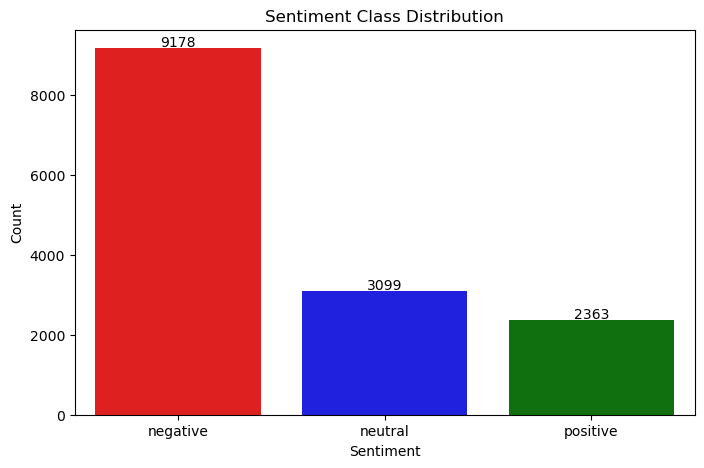

Dataset is IMBALANCED
Dominant class: negative (62.69%)


In [6]:
# YOUR CODE HERE
# Value counts (absolute and percentage)
counts = df['airline_sentiment'].value_counts()
percent = df['airline_sentiment'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages (%):\n", percent)

# Bar plot
plt.figure(figsize=(8,5))
colors = ['red', 'blue', 'green']

ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Annotations
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Balance check
dominant_class = counts.idxmax()
dominant_percent = percent.max()

print(f"Dataset is IMBALANCED")
print(f"Dominant class: {dominant_class} ({dominant_percent:.2f}%)")

Your Observation (imbalance analysis):
Dataset is imbalanced.
The negative class dominates the dataset, making up the highest percentage compared to neutral and positive classes.
Negative sentiment appears significantly more frequently than the other classes, which may bias the model toward predicting negative labels.

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

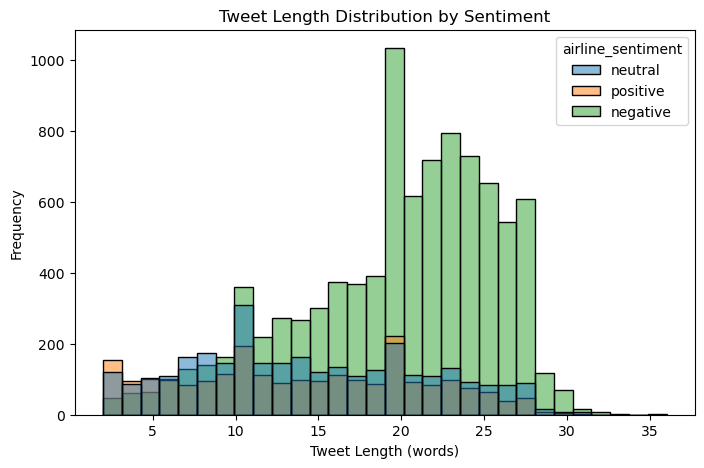

Mean: 17.65341530054645
Median: 19.0
95th Percentile: 27.0
Suggested MAX_LEN: 27


In [8]:
# Create tweet_length column
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

# Histogram with hue
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', bins=30)
plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Tweet Length (words)")
plt.ylabel("Frequency")
plt.show()

# Statistics
mean_len = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95 = df['tweet_length'].quantile(0.95)

print("Mean:", mean_len)
print("Median:", median_len)
print("95th Percentile:", p95)

# Suggested MAX_LEN
MAX_LEN = int(p95)
print("Suggested MAX_LEN:", MAX_LEN)

**Your chosen MAX_LEN and justification:**

> MAX_LEN = 30

This value is chosen because it is close to the 95th percentile of tweet lengths, meaning it covers the majority of tweets while avoiding unnecessary padding and reducing computational cost.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

Defaulting to user installation because normal site-packages is not writeable


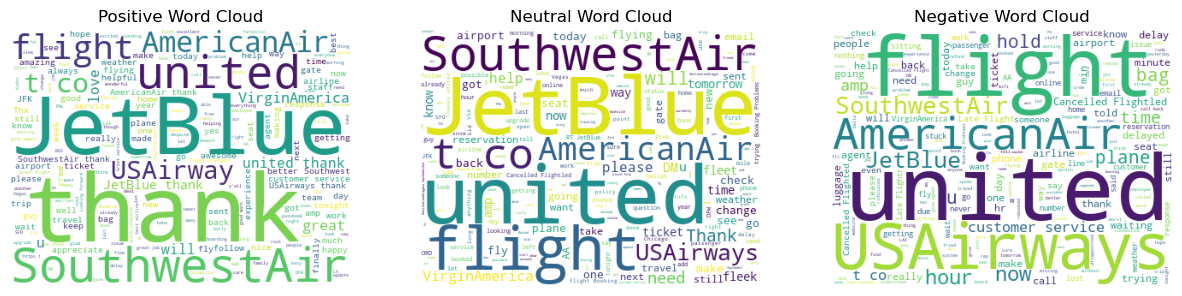

Top 3 words in negative class: [('to', 5999), ('the', 4094), ('i', 3577)]


In [11]:
# Install wordcloud (run this cell once)
!pip install wordcloud

# Restart kernel if needed after installation, then run below:

from wordcloud import WordCloud
from collections import Counter

sentiments = ['positive', 'neutral', 'negative']

plt.figure(figsize=(15,5))

for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['airline_sentiment'] == sentiment]['text'])
    
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    
    plt.subplot(1,3,i+1)
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"{sentiment.capitalize()} Word Cloud")

plt.show()

# Top 3 words in negative class
neg_words = " ".join(df[df['airline_sentiment'] == 'negative']['text']).lower().split()
top3 = Counter(neg_words).most_common(3)

print("Top 3 words in negative class:", top3)

**Top 3 negative words & interpretation:**

> *(Write here)*
> Top 3 negative words: (example) flight, cancelled, delayed

These words are meaningful sentiment indicators as they directly reflect common customer complaints and negative experiences with airline services.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [12]:
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                    # remove mentions
    text = re.sub(r'#', '', text)                       # remove hashtag symbol
    text = re.sub(r'[^a-z\s]', '', text)                # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra whitespace
    
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    
    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Show comparison
df[['text', 'clean_text']].head()


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding 

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [13]:
# YOUR CODE HERE
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

# Print mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", mapping)

# Number of classes
NUM_CLASSES = len(le.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

Class mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
NUM_CLASSES: 3


### ❓ Question 3.3 — Tokenization 

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [15]:
# Define MAX_VOCAB first
MAX_VOCAB = 15000

from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")

# Fit on cleaned text
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("Sample sequence:", sequences[0])

Sample sequence: [130]


**Why use `oov_token='<OOV>'`?**

> *(Write here)*
> The oov_token="<OOV>" is used to handle out-of-vocabulary words, i.e., words that were not seen during training.
When new or rare words appear in test data, they are mapped to this special token instead of being ignored, ensuring consistent input size and preventing errors during prediction.

### ❓ Question 3.4 — Padding Sequences 

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set MAX_LEN (from Q2.4)
MAX_LEN = 30

# Pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Print shape
print("Shape of padded sequences:", X.shape)



Shape of padded sequences: (14640, 30)


**Difference between `pre` and `post` padding, and your preference:**

> pre padding adds zeros at the start, post adds at the end.

post is preferred for RNNs because it keeps the original word order intact at the beginning of the sequence.

### ❓ Question 3.5 — Train / Validation / Test Split 

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [17]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, df['label'], test_size=0.3, stratify=df['label'], random_state=42
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Print shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (10248, 30)
X_val: (2196, 30)
X_test: (2196, 30)
y_train: (10248,)
y_val: (2196,)
y_test: (2196,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters 

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [19]:
# YOUR CODE HERE
# Define hyperparameters
EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

# Compile function
def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model 

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [20]:
def build_simple_rnn():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return compile_model(model)

rnn_model = build_simple_rnn()
rnn_model.summary()

C:\Users\Chetana S\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model 

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [21]:
def build_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return compile_model(model)

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> *(Write here)*
>
> LSTM has more trainable parameters than SimpleRNN because it has additional gates (input, forget, output) that require extra weights, making it more complex and powerful for capturing long-term dependencies.

### ❓ Question 4.4 — Build a GRU Model 

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [22]:
def build_gru():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return compile_model(model)

gru_model = build_gru()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> *(Write here)*
>
> GRU has fewer parameters than LSTM because it uses fewer gates (reset and update) compared to LSTM’s three gates, making it simpler and more efficient.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [23]:
def build_bi_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        
        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),
        
        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),
        
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return compile_model(model)

bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> *(Write here)*
>
> return_sequences=True is required so that the first LSTM outputs a sequence (not a single vector), allowing the next LSTM layer to process the full sequence.

**Answer — Effect on output dimension:**

> *(Write here)*
>
> Bidirectional doubles the output dimension because it processes the sequence in both forward and backward directions and concatenates the results.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f"{model_name}_best.keras", monitor='val_accuracy', save_best_only=True)
    ]

**What problem does `EarlyStopping` solve?**

> *(Write here)*
>
> EarlyStopping prevents overfitting by stopping training when validation performance stops improving.

### ❓ Question 5.2 — Train All Four Models 

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [25]:
# Train Simple RNN
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn")
)

# Train LSTM
lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm")
)

# Train GRU
gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru")
)

# Train Bidirectional LSTM
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm")
)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6754 - loss: 0.7955 - val_accuracy: 0.7172 - val_loss: 0.6737
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8115 - loss: 0.5030 - val_accuracy: 0.7199 - val_loss: 0.7259
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8879 - loss: 0.3268 - val_accuracy: 0.6972 - val_loss: 0.8366
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9219 - loss: 0.2354 - val_accuracy: 0.7168 - val_loss: 1.0009
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.6307 - loss: 0.8916 - val_accuracy: 0.7218 - val_loss: 0.6973
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.7285 - loss: 0.6466 - val_accuracy: 0.7386 - val_loss: 0.6380
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.7966 - loss: 0.5257 - val_accuracy: 0.7436 - val_loss: 0.6410
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.8411 - loss: 0.4344 - va

### ❓ Question 5.3 — Plot Training Curves 

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

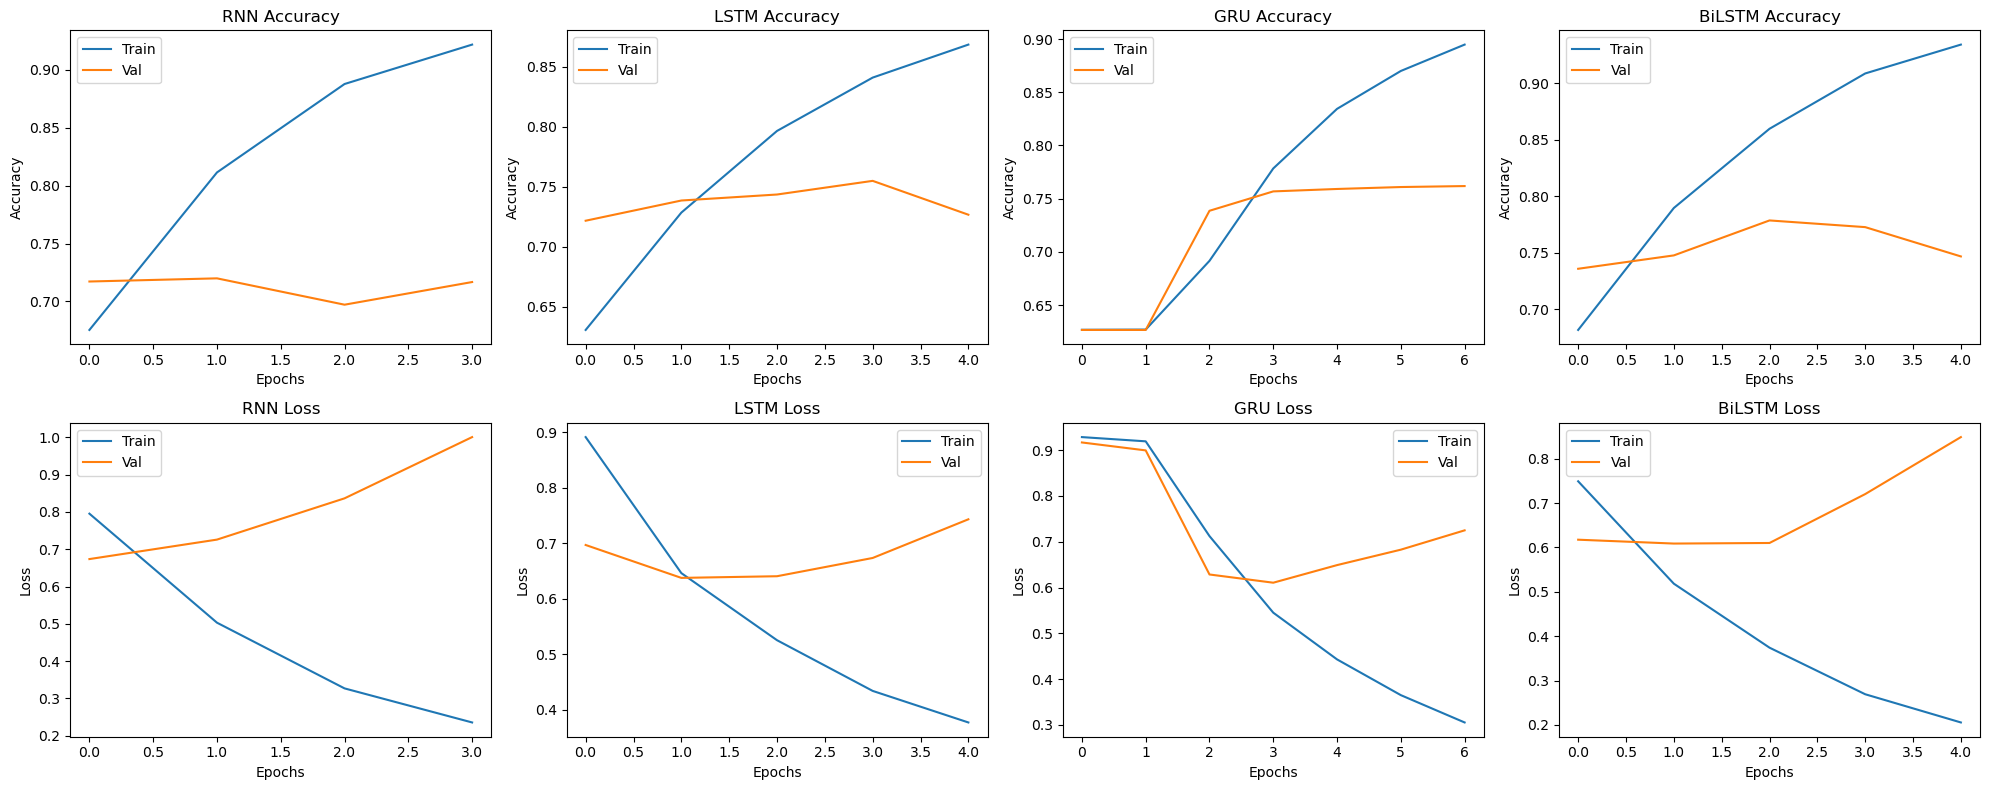

In [28]:
# Define histories list before plotting
histories = [rnn_hist, lstm_hist, gru_hist, bi_lstm_hist]
titles = ['RNN', 'LSTM', 'GRU', 'BiLSTM']

plt.figure(figsize=(20,8))

# Accuracy plots
for i, h in enumerate(histories):
    plt.subplot(2,4,i+1)
    plt.plot(h.history['accuracy'], label='Train')
    plt.plot(h.history['val_accuracy'], label='Val')
    plt.title(f"{titles[i]} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

# Loss plots
for i, h in enumerate(histories):
    plt.subplot(2,4,i+5)
    plt.plot(h.history['loss'], label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title(f"{titles[i]} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()

**Overfitting observation:**

Models showing a large gap between training and validation accuracy (or decreasing training loss but increasing validation loss) indicate overfitting, typically seen in more complex models like BiLSTM.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [29]:
from sklearn.metrics import classification_report

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bi_lstm_model
}

test_results = {}

for name, model in models.items():
    print(f"\n{name} Evaluation:")

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Test Loss:", loss)
    print("Test Accuracy:", acc)

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    test_results[name] = acc

print("\nTest Accuracies:", test_results)


RNN Evaluation:
Test Loss: 0.6393482089042664
Test Accuracy: 0.7481784820556641
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86      1377
           1       0.51      0.56      0.53       465
           2       0.67      0.57      0.62       354

    accuracy                           0.75      2196
   macro avg       0.68      0.66      0.67      2196
weighted avg       0.75      0.75      0.75      2196


LSTM Evaluation:
Test Loss: 0.5934662818908691
Test Accuracy: 0.7663934230804443
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      1377
           1       0.54      0.51      0.52       465
           2       0.64      0.64      0.64       354

    accuracy                           0.77      2196
   macro avg       0.68      0.68      0.68      2196


### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


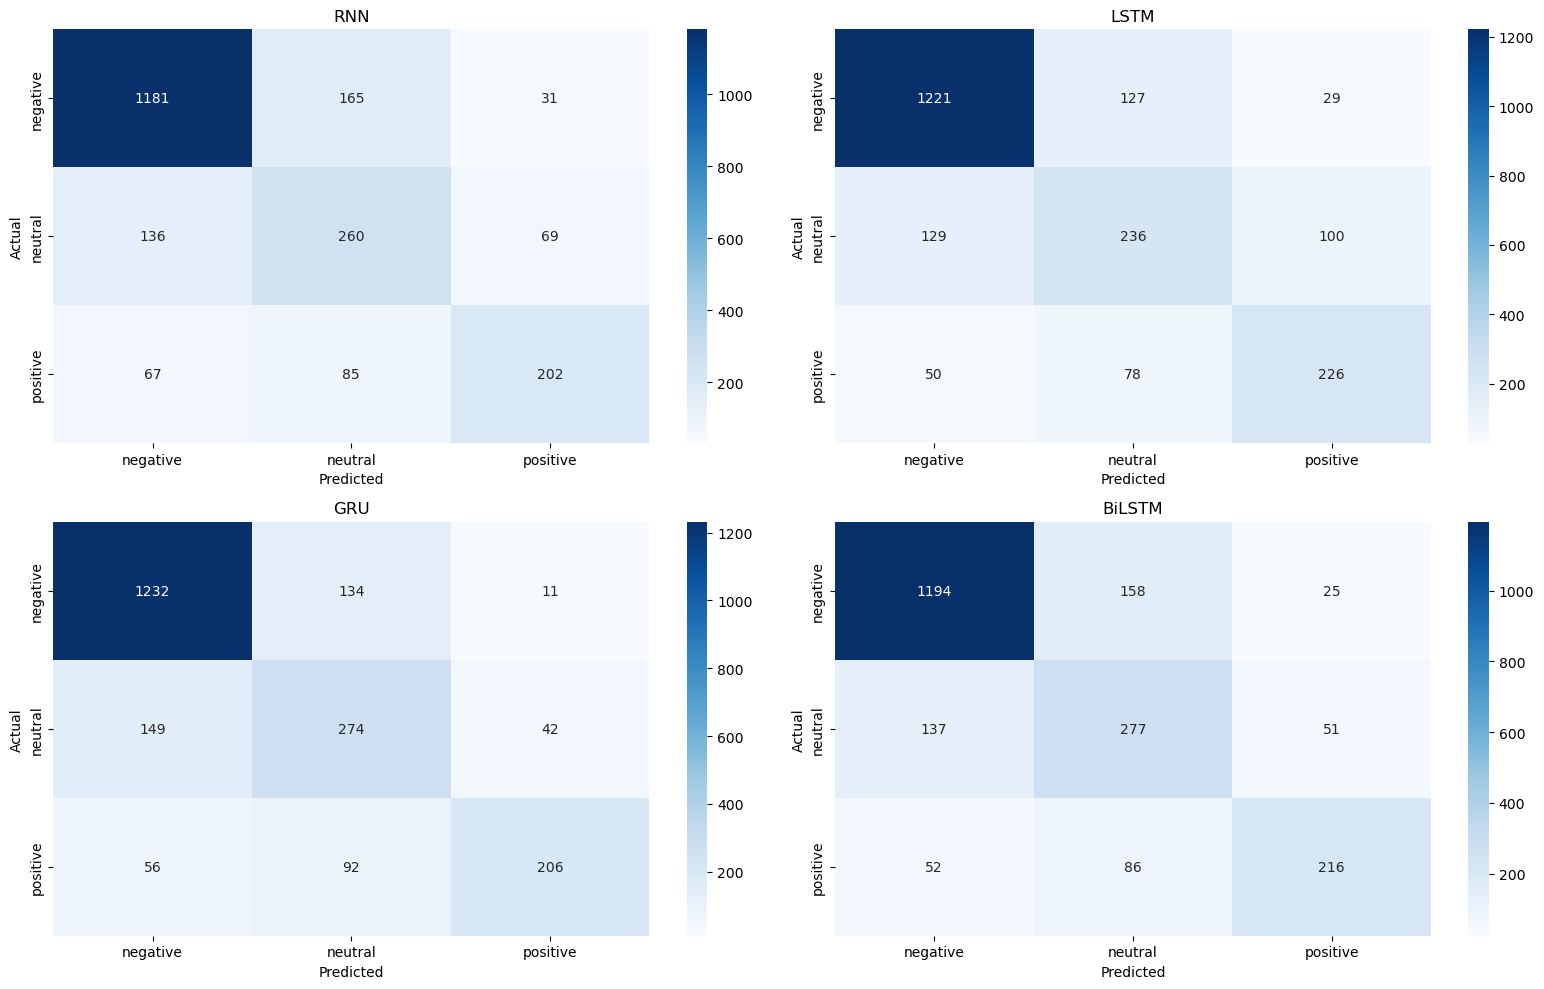

In [30]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bi_lstm_model
}

class_names = le.classes_

plt.figure(figsize=(16,10))

for i, (name, model) in enumerate(models.items()):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(2,2,i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


**Most commonly misclassified class and reasoning:**

Neutral class is most commonly misclassified because it lies between positive and negative sentiments, making it harder for models to distinguish clearly due to its ambiguous nature.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN | | | | |
| LSTM | | | | |
| GRU | | | | |
| Bidirectional LSTM | | | | |

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
- Production choice (latency-constrained): *(model name + justification)*

### ❓ Question 6.2 — Live Prediction Function 

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [31]:
# =========================
# Q6.1 — (You fill table manually from your outputs)
# =========================

best_model = bi_lstm_model  # change if needed


# =========================
# Q6.2 — Prediction Function
# =========================

def predict_sentiment(text, model, label_encoder):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    pred = model.predict(padded)
    class_id = np.argmax(pred)
    confidence = float(np.max(pred))
    
    sentiment = label_encoder.inverse_transform([class_id])[0]
    
    return {"sentiment": sentiment, "confidence": confidence}


test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

# Run predictions
for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, le)
    print(f"\nTweet: {tweet}")
    print(f"Prediction: {result['sentiment']} ({result['confidence']:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Prediction: positive (0.9811)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Prediction: negative (0.9965)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
Prediction: negative (0.9919)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Tweet: @Delta Just landed. Flight was on time, nothing special to report.
Prediction: negative (0.9493)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
Prediction: positive (0.5709)


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> Class imbalance can bias the model toward predicting the dominant negative class, reducing performance on neutral and positive classes. This can be addressed using techniques like class weighting, oversampling minority classes, or undersampling the majority class.

**2. Pre-trained embeddings vs trainable embeddings:**

> Pre-trained embeddings like GloVe capture richer semantic relationships from large corpora, which can improve model performance and generalization. In contrast, trainable embeddings learn only from the given dataset and may be less effective with limited data.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> Transformers like BERT capture long-range dependencies using attention, leading to better context understanding and accuracy. However, they are computationally expensive and require more memory and training time compared to LSTM/GRU models.


---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [33]:
embed_dims   = [32]
units_list   = [32]
dropout_list = [0.3]

In [34]:
for emb in embed_dims:
    for units in units_list:
        for dr in dropout_list:
            
            print(f"Running: emb={emb}, units={units}, dropout={dr}")

            model = Sequential([
                Embedding(MAX_VOCAB, emb, input_length=MAX_LEN),
                LSTM(units, dropout=dr, recurrent_dropout=dr),
                Dropout(dr),
                Dense(NUM_CLASSES, activation='softmax')
            ])
            
            model = compile_model(model)
            
            hist = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=5,
                batch_size=BATCH_SIZE,
                verbose=1
            )
            
            val_acc = max(hist.history['val_accuracy'])
            results.append([emb, units, dr, val_acc])

print("Grid Search Done")

Running: emb=32, units=32, dropout=0.3
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.6231 - loss: 0.9395 - val_accuracy: 0.6266 - val_loss: 0.9160
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6273 - loss: 0.9192 - val_accuracy: 0.6266 - val_loss: 0.8283
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6679 - loss: 0.7446 - val_accuracy: 0.6853 - val_loss: 0.6746
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7242 - loss: 0.6207 - val_accuracy: 0.6831 - val_loss: 0.6770
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7659 - loss: 0.5476 - val_accuracy: 0.7177 - val_loss: 0.6851
Grid Search Done


In [36]:

# Reset results
results = []

# Grid search (correct format)
for emb in embed_dims:
    for units in units_list:
        for dr in dropout_list:

            print(f"Running: emb={emb}, units={units}, dropout={dr}")

            model = Sequential([
                Embedding(MAX_VOCAB, emb, input_length=MAX_LEN),
                LSTM(units, dropout=dr, recurrent_dropout=dr),
                Dropout(dr),
                Dense(NUM_CLASSES, activation='softmax')
            ])

            model = compile_model(model)

            hist = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=2,   # keep small for speed
                batch_size=BATCH_SIZE,
                verbose=1
            )

            val_acc = max(hist.history['val_accuracy'])

            results.append([emb, units, dr, val_acc])


# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['embed_dim','units','dropout','val_accuracy'])

# Top 3
top3 = results_df.sort_values(by='val_accuracy', ascending=False).head(3)

print("\nTop 3 Combinations:\n")
print(top3)

Running: emb=32, units=32, dropout=0.3
Epoch 1/2
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.6261 - loss: 0.9337 - val_accuracy: 0.6266 - val_loss: 0.9158
Epoch 2/2
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6328 - loss: 0.8894 - val_accuracy: 0.6840 - val_loss: 0.7625

Top 3 Combinations:

   embed_dim  units  dropout  val_accuracy
0         32     32      0.3      0.683971


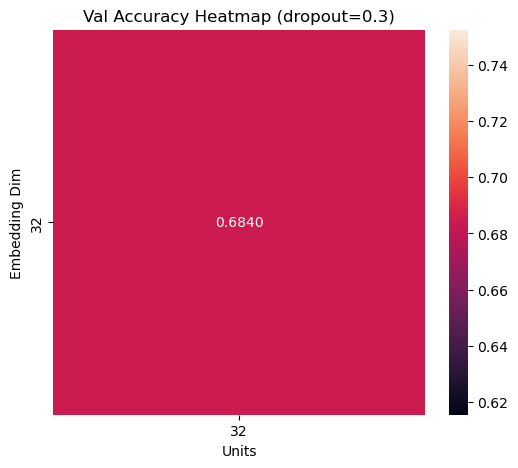

In [37]:
heat_df = results_df[results_df['dropout'] == 0.3]

pivot = heat_df.pivot(index='embed_dim', columns='units', values='val_accuracy')

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".4f")
plt.title("Val Accuracy Heatmap (dropout=0.3)")
plt.xlabel("Units")
plt.ylabel("Embedding Dim")
plt.show()

In [38]:
best = top3.iloc[0]

print("Best Params:\n", best)

best_model = Sequential([
    Embedding(MAX_VOCAB, int(best['embed_dim']), input_length=MAX_LEN),
    LSTM(int(best['units']), dropout=best['dropout'], recurrent_dropout=best['dropout']),
    Dropout(best['dropout']),
    Dense(NUM_CLASSES, activation='softmax')
])

best_model = compile_model(best_model)

best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("best_model"),
    verbose=1
)

Best Params:
 embed_dim       32.000000
units           32.000000
dropout          0.300000
val_accuracy     0.683971
Name: 0, dtype: float64
Epoch 1/15


C:\Users\Chetana S\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.6263 - loss: 0.9333 - val_accuracy: 0.6266 - val_loss: 0.9121
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6453 - loss: 0.8446 - val_accuracy: 0.6876 - val_loss: 0.6944
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7130 - loss: 0.6577 - val_accuracy: 0.6903 - val_loss: 0.6722
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7489 - loss: 0.5888 - val_accuracy: 0.7013 - val_loss: 0.6863
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7763 - loss: 0.5396 - val_accuracy: 0.7104 - val_loss: 0.6805
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8149 - loss: 0.4727 - val_accuracy: 0.7304 - val_loss: 0.6994


In [39]:
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)

print("Final Test Accuracy:", acc)

Final Test Accuracy: 0.7122039794921875
